# PHASE 1 — Environment Setup

### 1 — Install the required packages

In [12]:
!pip install numpy pandas matplotlib pillow scikit-learn tensorflow seaborn

Defaulting to user installation because normal site-packages is not writeable


###  — Verify the installation

In [13]:
import numpy as np
import pandas as pd
import matplotlib
import PIL
import sklearn
import tensorflow as tf
import seaborn as sns

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Pillow:", PIL.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)
print("Seaborn:", sns.__version__)

NumPy: 2.3.5
Pandas: 2.3.3
Matplotlib: 3.10.6
Pillow: 12.0.0
Scikit-learn: 1.7.2
TensorFlow: 2.21.0
Seaborn: 0.13.2


#### 2 — Import packages

In [14]:
import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("All packages imported successfully!")
print("TensorFlow version:", tf.__version__)

All packages imported successfully!
TensorFlow version: 2.21.0


# PHASE 2 — Dataset Preparation

#### 1 — Find your ZIP file

In [15]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders:")
for item in os.listdir():
    print(item)

Current working directory:
C:\Users\ISUG\Desktop\DA

Files and folders:
.freebuff
.ipynb_checkpoints
app.py
build_notebook.py
DA
DA.zip
digit.ipynb
digit_clean.ipynb
digit_recognition.ipynb
handwritten_digit_cnn.keras
inspect_full.py
inspect_nb.py
test_digit.jpg


###  2— Extract the ZIP file

In [16]:
import zipfile
import os

zip_path = "DA.zip"
extract_path = "DA"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [17]:
print(os.listdir("DA"))

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [18]:
dataset_path = "DA"

digits = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Classes:", digits)
print("Number of classes:", len(digits))

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Number of classes: 10


### 3 — Count images in each digit folder

In [19]:
dataset_path = "DA"

class_counts = {}

for digit in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, digit)

    if os.path.isdir(folder_path):
        image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif"))
        ]

        class_counts[digit] = len(image_files)

        print(f"Digit {digit}: {len(image_files)} images")

Digit 0: 152 images
Digit 1: 113 images
Digit 2: 142 images
Digit 3: 119 images
Digit 4: 143 images
Digit 5: 142 images
Digit 6: 133 images
Digit 7: 116 images
Digit 8: 116 images
Digit 9: 113 images


In [20]:
total_images = sum(class_counts.values())

print("\nTotal images:", total_images)


Total images: 1289


### 4 — Visualize the class distribution

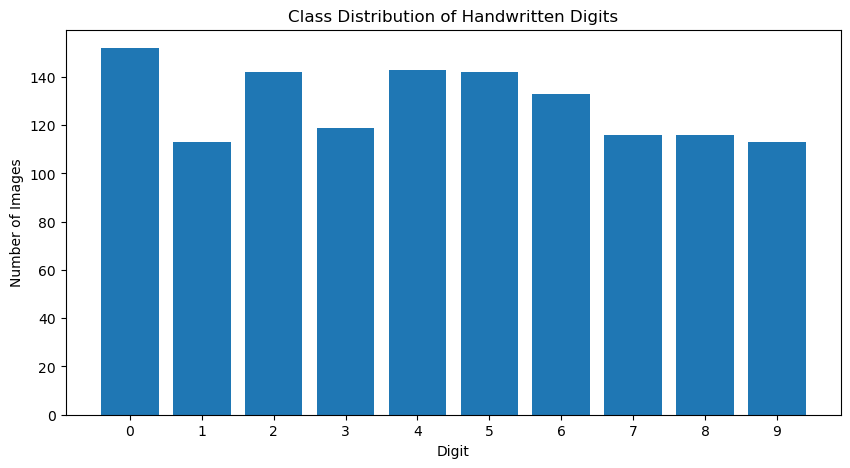

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Handwritten Digits")

plt.show()

In [22]:
from collections import Counter
from PIL import Image

sizes = Counter()
modes = Counter()

for digit in digits:
    folder_path = os.path.join(dataset_path, digit)

    for file in os.listdir(folder_path):
        if file.lower().endswith(valid_extensions):

            file_path = os.path.join(folder_path, file)

            try:
                with Image.open(file_path) as img:
                    sizes[img.size] += 1
                    modes[img.mode] += 1

            except Exception as e:
                print("Error:", file_path, e)

print("Image sizes:")
for size, count in sizes.items():
    print(size, ":", count)

print("\nImage modes:")
for mode, count in modes.items():
    print(mode, ":", count)

NameError: name 'valid_extensions' is not defined

In [ ]:
for digit, count in class_counts.items():
    print(f"Digit {digit}: {count}")

### 7 — Inspect image dimensions and color mode

In [ ]:
from collections import Counter

sizes = []
modes = []

for digit in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, digit)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif")):
            file_path = os.path.join(folder_path, file)

            try:
                img = Image.open(file_path)

                sizes.append(img.size)
                modes.append(img.mode)

            except Exception:
                pass

print("Image sizes:")
print(Counter(sizes))

print("\nImage modes:")
print(Counter(modes))

#### 8 — Display sample images

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digit in range(10):
    folder_path = os.path.join(dataset_path, str(digit))

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif"))
    ]

    image_path = os.path.join(folder_path, image_files[0])

    img = Image.open(image_path)

    axes[digit // 5, digit % 5].imshow(img, cmap="gray")
    axes[digit // 5, digit % 5].set_title(f"Digit {digit}")
    axes[digit // 5, digit % 5].axis("off")

plt.tight_layout()
plt.show()

### 9 — Check for corrupted images

In [ ]:
corrupted_files = []

for digit in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, digit)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif")):

            file_path = os.path.join(folder_path, file)

            try:
                with Image.open(file_path) as img:
                    img.verify()

            except Exception as e:
                corrupted_files.append(file_path)

print("Number of corrupted images:", len(corrupted_files))

if corrupted_files:
    print("\nCorrupted files:")
    for file in corrupted_files:
        print(file)

# PHASE 3 — Image Preprocessing

In [ ]:
IMG_SIZE = 28

print("Target image size:", IMG_SIZE, "x", IMG_SIZE)

### 10 — Load images into NumPy arrays

In [ ]:
images = []
labels = []

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

for digit in range(10):

    folder_path = os.path.join(dataset_path, str(digit))

    for file in os.listdir(folder_path):

        if file.lower().endswith(valid_extensions):

            file_path = os.path.join(folder_path, file)

            try:
                # Open image
                img = Image.open(file_path)

                # Convert to grayscale
                img = img.convert("L")

                # Resize
                img = img.resize((IMG_SIZE, IMG_SIZE))

                # Convert image to NumPy array
                img_array = np.array(img)

                # Store image and label
                images.append(img_array)
                labels.append(digit)

            except Exception as e:
                print("Error:", file_path, e)

X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

### 11 — Normalize the images

In [ ]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

In [ ]:
X = X.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

### 12 — Reshape the images

In [ ]:
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("X shape:", X.shape)

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X = X.reshape(-1, 28, 28, 1)

print("New X shape:", X.shape)

# PHASE 4 — Train / Validation / Test Split

### 1 — Split training and temporary data

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Temporary images:", len(X_temp))

### 2 — Split validation and test

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

### 3 — Check class distribution after splitting

### 3 — Check class distribution after splitting

In [ ]:
print("Training distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest distribution:")
print(pd.Series(y_test).value_counts().sort_index())

# PHASE 5 — Data Augmentation

### 1 — Create the augmentation pipeline

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10)
])

print("Data augmentation created successfully.")

### 2 — Visualize augmentation

In [ ]:
sample_image = X_train[0]

sample_batch = np.expand_dims(sample_image, axis=0)

plt.figure(figsize=(12, 4))

# Original
plt.subplot(1, 4, 1)
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"Original - Label {y_train[0]}")
plt.axis("off")

# Augmented images
for i in range(3):

    augmented = data_augmentation(
        sample_batch,
        training=True
    )

    plt.subplot(1, 4, i + 2)
    plt.imshow(augmented[0].numpy().squeeze(), cmap="gray")
    plt.title(f"Augmented {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 3 — Check that the digit is still recognizable

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

### 4 — Important: Don't augment X_train manually

Data augmentation is applied on-the-fly during training using the `data_augmentation` layer.
Do **not** try to manually pre-compute augmented images — the Keras layer handles this automatically.

# PHASE 6 — Build the CNN Model

### 1 — Create the model architecture

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="digit_cnn")

model.summary()

# PHASE 7 — Compile & Train

### 2 — Compile the model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Model compiled successfully.")

### 3 — Train the model

In [ ]:
history = model.fit(
    data_augmentation(X_train, training=True),
    y_train,
    epochs=80,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
)

### 4 — Plot training history

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

### 5 — Evaluate on the test set

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

### 6 — Generate predictions

In [ ]:
y_probability = model.predict(X_test)

y_pred = np.argmax(y_probability, axis=1)

print("Predicted labels:")
print(y_pred[:20])

print("\nActual labels:")
print(y_test[:20])

### 7 — Classification report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

### 8 — Confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

### 9 — Display predictions visually

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i].squeeze(), cmap="gray")

    predicted = y_pred[i]
    actual = y_test[i]

    plt.title(f"Pred: {predicted} | Actual: {actual}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 10 — Save the trained model

In [ ]:
model.save("handwritten_digit_cnn.keras")

print("Model saved successfully.")

### 11 — Test with a new handwritten image

In [ ]:
new_image_path = "test_digit.jpg"

img = Image.open(new_image_path).convert("L")
img = img.resize((28, 28))

img_array = np.array(img).astype("float32") / 255.0
img_array = img_array.reshape(1, 28, 28, 1)

prediction = model.predict(img_array)

predicted_digit = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted digit:", predicted_digit)
print("Confidence:", confidence)